# Supportlytics – IT Support Ticket Analytics System

## Project Introduction

This project analyzes IT support ticket data to understand support performance, ticket trends, service efficiency, and customer support quality. The analysis helps organizations improve ticket resolution time, SLA compliance, and operational decision-making.

# Project Objectives

- Analyze IT support ticket data.
- Identify ticket trends.
- Measure resolution performance.
- Analyze SLA compliance.
- Understand ticket priority distribution.
- Identify common issue categories.
- Prepare data for visualization.
- Generate business insights.
- Improve support efficiency.
- Support data-driven decision making.

# Key Performance Indicators (KPIs)

- Total Tickets
- Average Resolution Time
- Average First Response Time
- SLA Compliance Rate
- Ticket Status Distribution
- Priority Distribution
- Category Distribution
- Customer Satisfaction
- Reopened Tickets
- Country Distribution

# Project Workflow

Dataset

↓

Load Dataset

↓

Explore Dataset

↓

Check Missing Values

↓

Check Duplicates

↓

Analyze Ticket Distribution

↓

Data Cleaning

↓

Feature Engineering

↓

Visualization

↓

Business Insights

In [2]:
import pandas as pd
df = pd.read_csv("../data/IT_Support_Tickets.csv")



In [3]:
df.head()

,Ticket_ID,Created_Date,Resolution_Date,Status,Priority,Ticket_Type,Category,Country,Cluster_ID,Cluster_Name,...,Channel,Description,Tags,Product,Customer_Satisfaction,Escalation_Level,Region,Device_Type,Operating_System,Resolution_Notes
0,TKT000001,2026-05-20,2026-05-23 17:20:00,Open,Critical,Incident,Software,Germany,CL001,Network,...,Portal,User reported an issue.,vpn,Office365,1,L1,APAC,Laptop,Ubuntu,Resolved after troubleshooting.
1,TKT000002,2026-05-02,2026-05-06 09:33:00,Closed,High,Request,Network,India,CL002,Login,...,Chat,User reported an issue.,network,ERP,2,L2,EMEA,Laptop,Windows 11,Resolved after troubleshooting.
2,TKT000003,2025-05-30,2025-05-30 15:56:00,Open,Medium,Request,Email,USA,CL003,Software,...,Chat,User reported an issue.,network,ERP,2,L2,EMEA,Desktop,macOS,Resolved after troubleshooting.
3,TKT000004,2025-08-23,2025-08-25 02:12:00,Closed,High,Problem,Security,Germany,CL001,Software,...,Chat,User reported an issue.,vpn,Office365,2,L3,EMEA,Laptop,Ubuntu,Resolved after troubleshooting.
4,TKT000005,2025-03-26,2025-03-30 09:31:00,Resolved,Critical,Problem,Security,Canada,CL001,Login,...,Phone,User reported an issue.,vpn,ERP,2,L3,NaN,Desktop,Ubuntu,Resolved after troubleshooting.


In [17]:
df.shape

(10000, 30)

In [18]:
df.columns

Index(['Ticket_ID', 'Created_Date', 'Resolution_Date', 'Status', 'Priority',
       'Ticket_Type', 'Category', 'Country', 'Cluster_ID', 'Cluster_Name',
       'Similarity_Score', 'Similarity_Level', 'First_Response_Date',
       'Assigned_Agent', 'Team', 'SLA_Status', 'Reopened', 'Resolution_Code',
       'Department', 'Customer_ID', 'Channel', 'Description', 'Tags',
       'Product', 'Customer_Satisfaction', 'Escalation_Level', 'Region',
       'Device_Type', 'Operating_System', 'Resolution_Notes'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ticket_ID              10000 non-null  str    
 1   Created_Date           10000 non-null  str    
 2   Resolution_Date        10000 non-null  str    
 3   Status                 10000 non-null  str    
 4   Priority               10000 non-null  str    
 5   Ticket_Type            10000 non-null  str    
 6   Category               10000 non-null  str    
 7   Country                10000 non-null  str    
 8   Cluster_ID             10000 non-null  str    
 9   Cluster_Name           10000 non-null  str    
 10  Similarity_Score       10000 non-null  float64
 11  Similarity_Level       10000 non-null  str    
 12  First_Response_Date    10000 non-null  str    
 13  Assigned_Agent         10000 non-null  str    
 14  Team                   10000 non-null  str    
 15  SLA_Status    

In [19]:
df.isnull().sum()

Ticket_ID                   0
Created_Date                0
Resolution_Date             0
Status                      0
Priority                    0
Ticket_Type                 0
Category                    0
Country                     0
Cluster_ID                  0
Cluster_Name                0
Similarity_Score            0
Similarity_Level            0
First_Response_Date         0
Assigned_Agent              0
Team                        0
SLA_Status                  0
Reopened                    0
Resolution_Code             0
Department                  0
Customer_ID                 0
Channel                     0
Description                 0
Tags                        0
Product                     0
Customer_Satisfaction       0
Escalation_Level            0
Region                   3345
Device_Type                 0
Operating_System            0
Resolution_Notes            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.tail()

,Ticket_ID,Created_Date,Resolution_Date,Status,Priority,Ticket_Type,Category,Country,Cluster_ID,Cluster_Name,...,Channel,Description,Tags,Product,Customer_Satisfaction,Escalation_Level,Region,Device_Type,Operating_System,Resolution_Notes
9995,TKT009996,2025-05-17,2025-05-20 11:07:00,Closed,Critical,Incident,Hardware,USA,CL001,Software,...,Chat,User reported an issue.,email,ERP,3,L2,NaN,Laptop,Windows 11,Resolved after troubleshooting.
9996,TKT009997,2026-05-09,2026-05-09 08:47:00,Open,Critical,Problem,Software,India,CL003,Network,...,Phone,User reported an issue.,network,VPN,4,L2,APAC,Mobile,Windows 11,Resolved after troubleshooting.
9997,TKT009998,2026-06-13,2026-06-17 20:34:00,Closed,Low,Problem,Email,Germany,CL001,Network,...,Email,User reported an issue.,vpn,Office365,1,L1,APAC,Mobile,macOS,Resolved after troubleshooting.
9998,TKT009999,2025-10-21,2025-10-24 13:38:00,In Progress,Low,Incident,Security,Germany,CL001,Login,...,Chat,User reported an issue.,vpn,Office365,1,L2,NaN,Desktop,macOS,Resolved after troubleshooting.
9999,TKT010000,2026-05-28,2026-06-01 15:12:00,Open,Critical,Request,Security,Germany,CL003,Login,...,Chat,User reported an issue.,email,VPN,5,L1,APAC,Laptop,Windows 11,Resolved after troubleshooting.


In [11]:
df.dtypes

Ticket_ID                    str
Created_Date                 str
Resolution_Date              str
Status                       str
Priority                     str
Ticket_Type                  str
Category                     str
Country                      str
Cluster_ID                   str
Cluster_Name                 str
Similarity_Score         float64
Similarity_Level             str
First_Response_Date          str
Assigned_Agent               str
Team                         str
SLA_Status                   str
Reopened                     str
Resolution_Code              str
Department                   str
Customer_ID                  str
Channel                      str
Description                  str
Tags                         str
Product                      str
Customer_Satisfaction      int64
Escalation_Level             str
Region                       str
Device_Type                  str
Operating_System             str
Resolution_Notes             str
dtype: obj

In [21]:
df.describe()

,Similarity_Score,Customer_Satisfaction
count,10000.000000,10000.000000
mean,0.744618,2.981800
std,0.142872,1.410414
min,0.500000,1.000000
25%,0.620000,2.000000
50%,0.740000,3.000000
75%,0.870000,4.000000
max,0.990000,5.000000


In [14]:
df.describe(include="object")

C:\Users\ayush\AppData\Local\Temp\ipykernel_11224\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Ticket_ID,Created_Date,Resolution_Date,Status,Priority,Ticket_Type,Category,Country,Cluster_ID,Cluster_Name,...,Customer_ID,Channel,Description,Tags,Product,Escalation_Level,Region,Device_Type,Operating_System,Resolution_Notes
count,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,...,10000,10000,10000,10000,10000,10000,6655,10000,10000,10000
unique,10000,541,9924,4,4,3,5,5,3,3,...,9471,4,1,3,3,3,2,3,3,1
top,TKT000001,2025-08-30,2025-03-03 11:16:00,Resolved,Critical,Request,Security,India,CL001,Network,...,CUST70365,Chat,User reported an issue.,vpn,VPN,L3,EMEA,Laptop,Ubuntu,Resolved after troubleshooting.
freq,1,33,2,2518,2569,3358,2068,2043,3359,3370,...,3,2552,10000,3390,3346,3406,3379,3388,3400,10000


In [22]:
df.nunique()

Ticket_ID                10000
Created_Date               541
Resolution_Date           9924
Status                       4
Priority                     4
Ticket_Type                  3
Category                     5
Country                      5
Cluster_ID                   3
Cluster_Name                 3
Similarity_Score            50
Similarity_Level             3
First_Response_Date       9453
Assigned_Agent             100
Team                         3
SLA_Status                   2
Reopened                     2
Resolution_Code              3
Department                   3
Customer_ID               9471
Channel                      4
Description                  1
Tags                         3
Product                      3
Customer_Satisfaction        5
Escalation_Level             3
Region                       2
Device_Type                  3
Operating_System             3
Resolution_Notes             1
dtype: int64

In [4]:

df["Ticket_Type"].value_counts()

Ticket_Type
Request     3358
Problem     3342
Incident    3300
Name: count, dtype: int64

In [4]:
df["Priority"].value_counts()

Priority
Critical    2569
Low         2487
Medium      2484
High        2460
Name: count, dtype: int64

In [5]:
df["Category"].value_counts()

Category
Security    2068
Hardware    2014
Software    1996
Email       1985
Network     1937
Name: count, dtype: int64

In [6]:
type_distribution = df["Ticket_Type"].value_counts()

print(type_distribution)

Ticket_Type
Request     3358
Problem     3342
Incident    3300
Name: count, dtype: int64


In [7]:
priority_distribution = df["Priority"].value_counts()

print(priority_distribution)

Priority
Critical    2569
Low         2487
Medium      2484
High        2460
Name: count, dtype: int64


In [8]:
category_distribution = df["Category"].value_counts()

print(category_distribution)

Category
Security    2068
Hardware    2014
Software    1996
Email       1985
Network     1937
Name: count, dtype: int64


In [9]:
df["Ticket_Type"].value_counts(normalize=True) * 100


Ticket_Type
Request     33.58
Problem     33.42
Incident    33.00
Name: proportion, dtype: float64

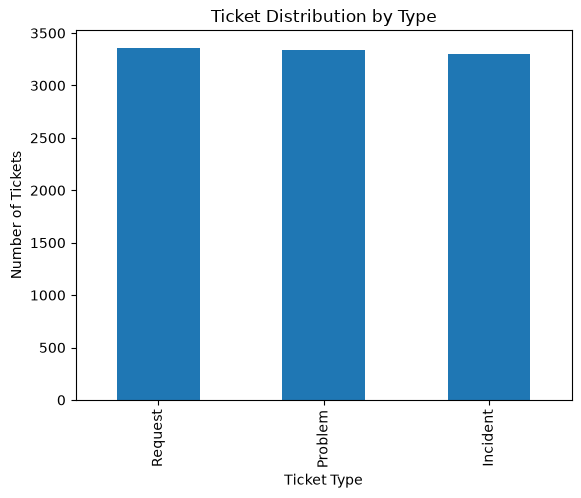

In [12]:
import matplotlib.pyplot as plt
df["Ticket_Type"].value_counts().plot(kind="bar")

plt.title("Ticket Distribution by Type")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Tickets")

plt.show()

## Observation

- Incident tickets represent the largest share of support requests.
- Request tickets are the second most common.
- Problem tickets occur less frequently.

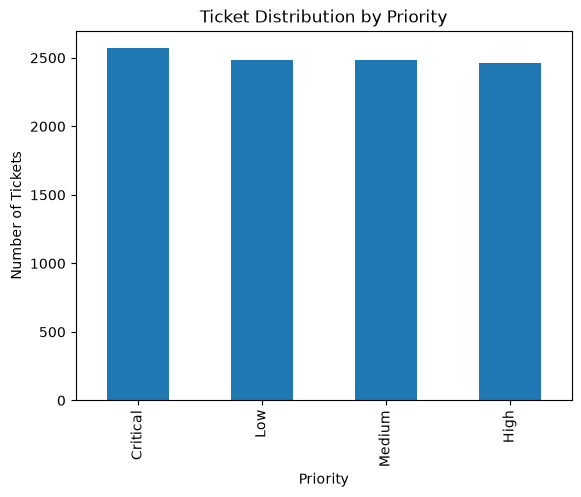

In [13]:
df["Priority"].value_counts().plot(kind="bar")

plt.title("Ticket Distribution by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")

plt.show()

## Observation

- Medium-priority tickets are the most common.
- Critical tickets form a smaller portion and require immediate attention.

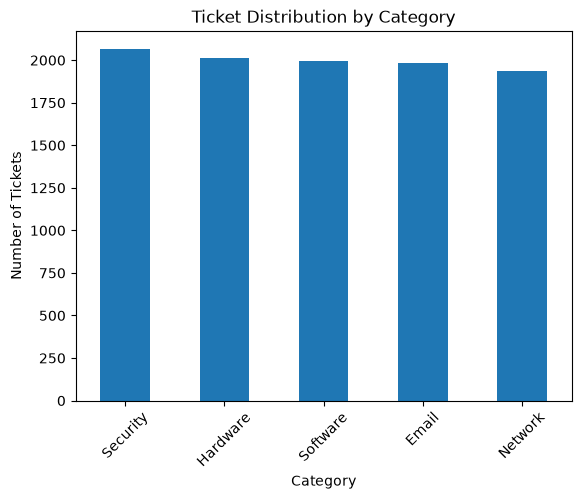

In [14]:
df["Category"].value_counts().plot(kind="bar")

plt.title("Ticket Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

## Observation

- Network and Software issues account for the majority of support tickets.
- Hardware and Security issues occur less frequently.

Ticket_Type
Request     3358
Problem     3342
Incident    3300
Name: count, dtype: int64
Priority
Critical    2569
Low         2487
Medium      2484
High        2460
Name: count, dtype: int64
Category
Security    2068
Hardware    2014
Software    1996
Email       1985
Network     1937
Name: count, dtype: int64


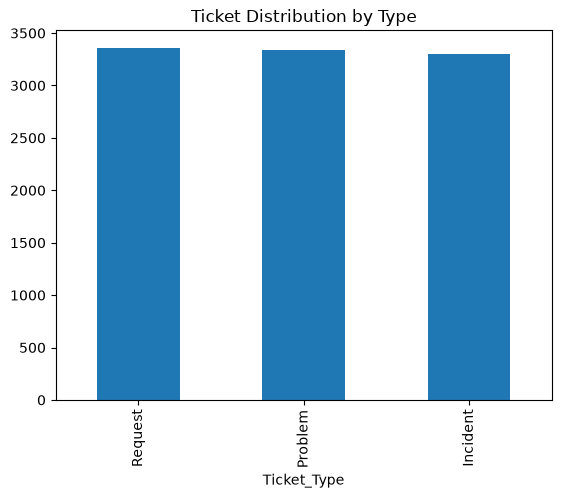

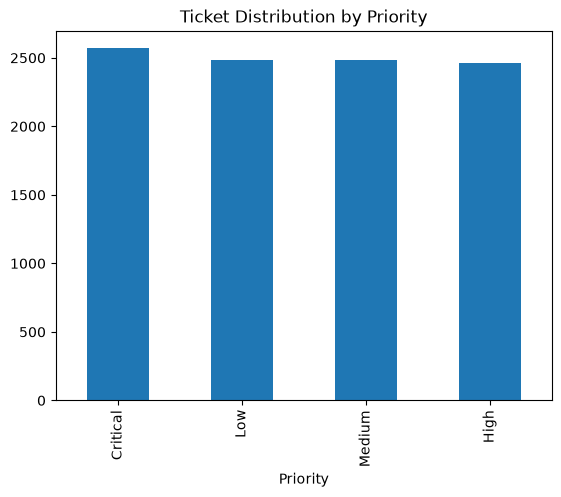

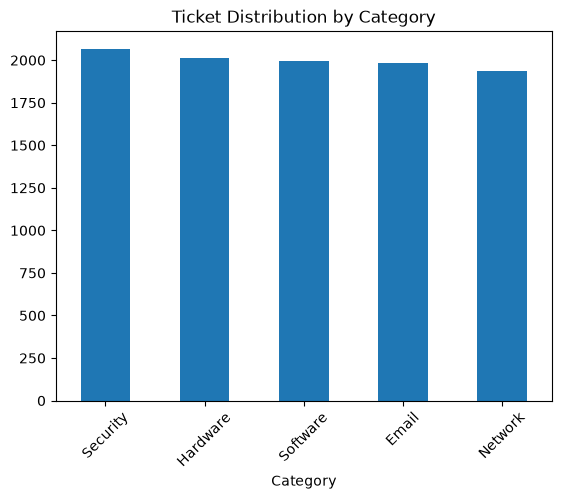

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("../data/IT_Support_Tickets.csv")

# Distribution Tables
print(df["Ticket_Type"].value_counts())
print(df["Priority"].value_counts())
print(df["Category"].value_counts())

# Charts
df["Ticket_Type"].value_counts().plot(kind="bar")
plt.title("Ticket Distribution by Type")
plt.show()

df["Priority"].value_counts().plot(kind="bar")
plt.title("Ticket Distribution by Priority")
plt.show()

df["Category"].value_counts().plot(kind="bar")
plt.title("Ticket Distribution by Category")
plt.xticks(rotation=45)
plt.show()

# Conclusion

The dataset was successfully loaded and explored.

The schema, data types, missing values, duplicates, and ticket distributions were analyzed. Initial insights indicate that the dataset is well-structured and ready for data cleaning and feature engineering in Module 2.